<a href="https://colab.research.google.com/github/busrabhcc/Dogal-Dil-Isleme/blob/main/dogaldilisleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# Klasör yolunu kendi klasör adına göre güncelle
base_path = '/content/drive/MyDrive/dataset'

def verileri_oku(ana_dizin):
    veriler = []
    # Klasördeki türleri listele (pop, rap, arabesk vb.)
    turler = [f for f in os.listdir(ana_dizin) if os.path.isdir(os.path.join(ana_dizin, f))]

    for tur in turler:
        tur_yolu = os.path.join(ana_dizin, tur)
        for dosya in os.listdir(tur_yolu):
            if dosya.endswith('.txt'):
                file_path = os.path.join(tur_yolu, dosya)
                # Encoding 'utf-8' veya 'latin-1' gerekebilir
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    veriler.append({'metin': f.read(), 'tur': tur})

    return pd.DataFrame(veriler)

df = verileri_oku(base_path)
print(f"Toplam okunan şarkı sayısı: {len(df)}")
print(df['tur'].value_counts()) # Tür dağılımını kontrol et

Toplam okunan şarkı sayısı: 121
tur
pop             31
anadolu_rock    30
türkü         24
türkçe_rap    20
arabesk         16
Name: count, dtype: int64


In [ ]:
# Türkçe NLP için Zeyrek kütüphanesini kur
!pip install zeyrek
import zeyrek

analyzer = zeyrek.MorphAnalyzer()

def temizle_ve_kok_bul(metin):
    # Küçük harf ve noktalama temizliği
    metin = metin.lower()
    # Basit bir temizleme (daha gelişmişi regex ile yapılabilir)
    kelimeler = metin.split()

    temiz_metin = []
    for k in kelimeler:
        # Zeyrek ile kelimenin kökünü bul
        analiz = analyzer.lemmatize(k)
        if analiz:
            # En olası kökü al
            temiz_metin.append(analiz[0][1][0])
        else:
            temiz_metin.append(k)

    return " ".join(temiz_metin)
print(df.head())

# Ayrıca veri setinin genel özetini ve eksik veri olup olmadığını görmek için:
print(df.info())
# Örnek uygulama
# df['temiz_metin'] = df['metin'].apply(temizle_ve_kok_bul)

                                               metin  tur
0  Sevdik, sevildik, alıştık ve ayrıldık\nBiz aşk...  pop
1  Kimini dudağından\nKimini gözünden\nKimini düş...  pop
2  Nasıl kırılmasın kalbim?\nŞimdilik paramparça,...  pop
3  Aşk güzel şey geri çevirme\nOlmaz deme, duymaz...  pop
4  Cennetten bi' parça\nNasıl güvenmez insan?\nPe...  pop
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   metin   121 non-null    object
 1   tur     121 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB
None


In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords

# Eksik paketleri indir
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words_tr = set(stopwords.words('turkish'))

import zeyrek
analyzer = zeyrek.MorphAnalyzer()

def temizle_ve_kok_bul(metin):
    # Metin boşsa hata vermemesi için kontrol
    if not isinstance(metin, str):
        return ""

    # Küçük harfe çevirme ve Noktalama temizliği
    metin = metin.lower()
    metin = re.sub(r'[^\w\s]', '', metin)
    metin = re.sub(r'\d+', '', metin)

    kelimeler = metin.split()

    temiz_metin = []
    for k in kelimeler:
        if k not in stop_words_tr:
            analiz = analyzer.lemmatize(k)
            if analiz:
                # Zeyrek'in bulduğu ilk kökü alıyoruz
                kok = analiz[0][1][0]
                temiz_metin.append(kok)
            else:
                temiz_metin.append(k)

    return " ".join(temiz_metin)

print("Metinler temizleniyor ve kökler bulunuyor... Lütfen bekleyin.")
df['temiz_metin'] = df['metin'].apply(temizle_ve_kok_bul)

print("\nİşlem tamamlandı! İlk 5 sonuç:")
print(df[['metin', 'temiz_metin']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Metinler temizleniyor ve kökler bulunuyor... Lütfen bekleyin.


Görüntülenen çıkış son 5000 satıra kısaltıldı.



İşlem tamamlandı! İlk 5 sonuç:
                                               metin  \
0  Sevdik, sevildik, alıştık ve ayrıldık\nBiz aşk...   
1  Kimini dudağından\nKimini gözünden\nKimini düş...   
2  Nasıl kırılmasın kalbim?\nŞimdilik paramparça,...   
3  Aşk güzel şey geri çevirme\nOlmaz deme, duymaz...   
4  Cennetten bi' parça\nNasıl güvenmez insan?\nPe...   

                                         temiz_metin  
0  sevmek Sevil alışmak ayırmak aşk meğer bir oy ...  
1  kimi dudak kimi göz kimi düşünmek zeki söz kim...  
2  kırmak kalbî şimdilik paramparça Of mmh geçmek...  
3  aşk güzel geri çevirme olmaz de duymak de onma...  
4  cennet bi parça güvenmek İnsa pelerin örtmek b...  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Kelimeleri sayılara dökme (Tokenization)
max_words = 5000  # En sık geçen 5000 kelimeyi sözlüğe al
max_len = 150     # Her şarkıyı 150 kelimeyle sınırla (Bi-LSTM için ideal uzunluk)

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['temiz_metin'])

X = tokenizer.texts_to_sequences(df['temiz_metin'])
X = pad_sequences(X, maxlen=max_len) # Kısa metinleri 0 ile doldurur

# 2. Türleri (Etiketleri) sayılara dökme
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['tur'])
y_categorical = to_categorical(y_encoded) # 5 tür olduğu için One-Hot formatına çevir

# 3. Veriyi Eğitim ve Test olarak ayırma (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.20, random_state=42)

print(f"Eğitim veri seti boyutu: {X_train.shape}")
print(f"Test veri seti boyutu: {X_test.shape}")
print(f"Türlerin sayısal karşılığı: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Eğitim veri seti boyutu: (96, 150)
Test veri seti boyutu: (25, 150)
Türlerin sayısal karşılığı: {'anadolu_rock': 0, 'arabesk': 1, 'pop': 2, 'türkçe_rap': 3, 'türkü': 4}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([
    # Giriş Katmanı: Kelime vektörlerini oluşturur
    Embedding(input_dim=max_words, output_dim=100, input_length=max_len),

    # Ana Katman: Çift yönlü LSTM (Her yönde 64 nöron)
    Bidirectional(LSTM(64, return_sequences=False)),

    # Dropout: Ezberlemeyi (overfitting) önlemek için nöronların %30'unu rastgele kapatır
    Dropout(0.3),

    # Dense: Ara katman
    Dense(32, activation='relu'),

    # Çıkış Katmanı: 5 tür için olasılık üretir (Softmax)
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Model eğitiliyor... 121 şarkı olduğu için hızlı bitecektir.")
history = model.fit(X_train, y_train,
                    epochs=20,          # Veri az olduğu için 20 tur yeterli
                    batch_size=16,      # Her adımda 16 şarkı işle
                    validation_data=(X_test, y_test),
                    verbose=1)

Model eğitiliyor... 121 şarkı olduğu için hızlı bitecektir.
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.3333 - loss: 1.5924 - val_accuracy: 0.1200 - val_loss: 1.6109
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4896 - loss: 1.5315 - val_accuracy: 0.1200 - val_loss: 1.6085
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.4479 - loss: 1.4445 - val_accuracy: 0.1200 - val_loss: 1.6336
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.4583 - loss: 1.3666 - val_accuracy: 0.1200 - val_loss: 1.6188
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5625 - loss: 1.2159 - val_accuracy: 0.3200 - val_loss: 1.5058
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.6771 - loss: 0.8856 - val_accuracy: 0.3600 - val_loss: 1.9499
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.6458 - loss: 0.9481 - val_accuracy: 0.3600 - val_loss: 1.7848
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


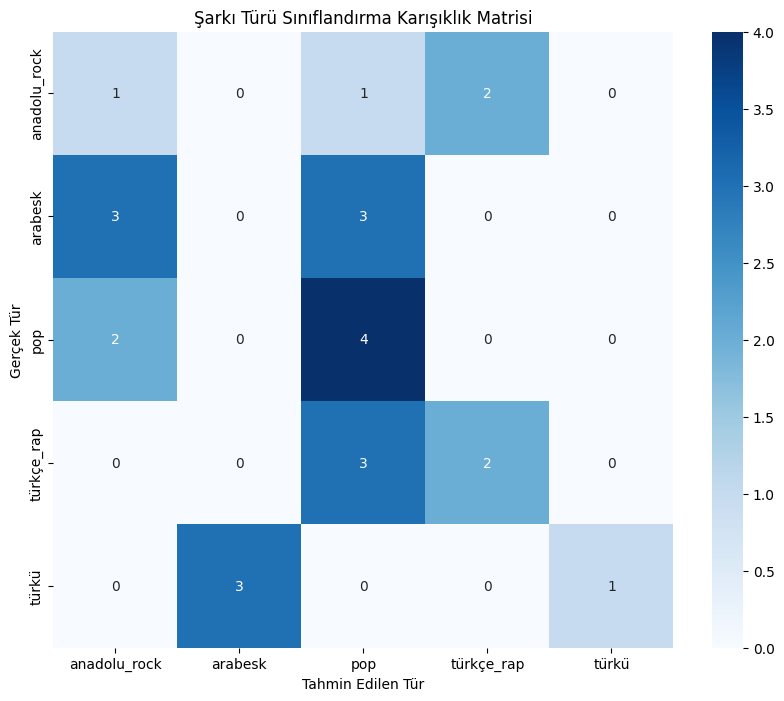

              precision    recall  f1-score   support

anadolu_rock       0.17      0.25      0.20         4
     arabesk       0.00      0.00      0.00         6
         pop       0.36      0.67      0.47         6
türkçe_rap       0.50      0.40      0.44         5
     türkü       1.00      0.25      0.40         4

    accuracy                           0.32        25
   macro avg       0.41      0.31      0.30        25
weighted avg       0.37      0.32      0.30        25



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Test verisi üzerinde tahmin yapma
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Confusion Matrix Oluşturma
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Tahmin Edilen Tür')
plt.ylabel('Gerçek Tür')
plt.title('Şarkı Türü Sınıflandırma Karışıklık Matrisi')
plt.show()

# 3. Detaylı Rapor
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))